Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 10: Algoritma Klasifikasi (Bagian 2)


## Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)

print('Library berhasil diimport')


Library berhasil diimport


## Langkah 1: Muat dan Eksplorasi Data

Dataset **Telco Customer Churn** (publik, IBM). Target `Churn` (Yes/No). Proporsi kelas dicek untuk memastikan data imbalanced.


In [2]:
URL = (
    'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/'
    'master/data/Telco-Customer-Churn.csv'
)
df = pd.read_csv(URL)

print('Shape:', df.shape)
print()
print(df.dtypes)
print()
print('Distribusi Churn:')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))
print()
print('TotalCharges kosong (string blank):',
      (df['TotalCharges'].astype(str).str.strip() == '').sum())


Shape: (7043, 21)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Distribusi Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

TotalCharges kosong (string blank): 11


## Langkah 2: Preprocessing

`customerID` dibuang (bukan fitur). `TotalCharges` dikonversi ke numerik — 11 baris kosong (tenure = 0) diisi 0. Fitur kategorikal di-encode dengan `pd.get_dummies()`. Split 80:20 **stratified** agar proporsi churn di train dan test sama. Penanganan imbalance hanya boleh di data latih; test set tetap distribusi asli.


In [3]:
df = df.drop(columns=['customerID'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
y = (df['Churn'] == 'Yes').astype(int)
X = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Fitur setelah encoding:', X.shape[1])
print('Train:', X_tr.shape, '| Test:', X_te.shape)
print('Proporsi churn train:', y_tr.mean().round(3))
print('Proporsi churn test :', y_te.mean().round(3))


Fitur setelah encoding: 30
Train: (5634, 30) | Test: (1409, 30)
Proporsi churn train: 0.265
Proporsi churn test : 0.265


## Langkah 3: Latih Model

Dua skenario dibanding pada test set yang sama:

1. Random Forest **tanpa** penanganan imbalance — menampilkan accuracy paradox
2. Random Forest dengan `class_weight="balanced"` — sesuai langkah modul


In [4]:
rf_base = RandomForestClassifier(n_estimators=300, random_state=42)
rf_base.fit(X_tr, y_tr)

rf_bal = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42
)
rf_bal.fit(X_tr, y_tr)

print('Kedua model selesai dilatih')


Kedua model selesai dilatih


## Langkah 4: Evaluasi

Fokus metrik pada **kelas churn (1)**. Accuracy dihitung juga, supaya terlihat mengapa angka itu menyesatkan pada data tidak seimbang.


=== Random Forest (tanpa penanganan) ===
Confusion Matrix [baris=aktual, kolom=prediksi | 0=No, 1=Churn]:
[[923 112]
 [178 196]]
Accuracy        : 0.794
Precision churn : 0.636
Recall churn    : 0.524
F1-Score churn  : 0.575
ROC-AUC         : 0.827



=== Random Forest (class_weight=balanced) ===
Confusion Matrix [baris=aktual, kolom=prediksi | 0=No, 1=Churn]:
[[928 107]
 [186 188]]
Accuracy        : 0.792
Precision churn : 0.637
Recall churn    : 0.503
F1-Score churn  : 0.562
ROC-AUC         : 0.826



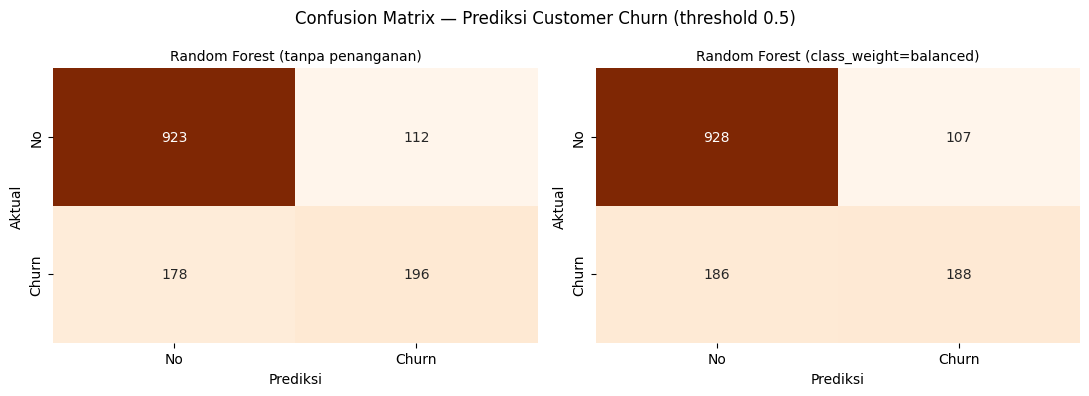

              precision    recall  f1-score   support

          No      0.833     0.897     0.864      1035
       Churn      0.637     0.503     0.562       374

    accuracy                          0.792      1409
   macro avg      0.735     0.700     0.713      1409
weighted avg      0.781     0.792     0.784      1409



In [5]:
def ringkas(nama, y_true, pred, proba):
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, pos_label=1)
    rec = recall_score(y_true, pred, pos_label=1)
    f1 = f1_score(y_true, pred, pos_label=1)
    auc = roc_auc_score(y_true, proba)
    print(f'=== {nama} ===')
    print('Confusion Matrix [baris=aktual, kolom=prediksi | 0=No, 1=Churn]:')
    print(cm)
    print(f'Accuracy        : {acc:.3f}')
    print(f'Precision churn : {prec:.3f}')
    print(f'Recall churn    : {rec:.3f}')
    print(f'F1-Score churn  : {f1:.3f}')
    print(f'ROC-AUC         : {auc:.3f}')
    print()
    return cm, acc, prec, rec, f1, auc, pred, proba

hasil = {}
for nama, model in [
    ('Random Forest (tanpa penanganan)', rf_base),
    ('Random Forest (class_weight=balanced)', rf_bal),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    hasil[nama] = ringkas(nama, y_te, pred, proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nama, (cm, *rest)) in zip(axes, hasil.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
        xticklabels=['No', 'Churn'],
        yticklabels=['No', 'Churn']
    )
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.set_title(nama, fontsize=10)
plt.suptitle('Confusion Matrix — Prediksi Customer Churn (threshold 0.5)')
plt.tight_layout()
plt.show()

print(classification_report(
    y_te, hasil['Random Forest (class_weight=balanced)'][6],
    target_names=['No', 'Churn'], digits=3
))


## Langkah 4b: Threshold Tuning

Ambang default 0.5 sering terlalu ketat untuk kelas minoritas. Modul menyarankan menurunkan threshold agar Recall churn naik (dengan konsekuensi Precision bisa turun).


 threshold  Accuracy  Precision  Recall    F1
      0.50     0.792      0.637   0.503 0.562
      0.40     0.780      0.581   0.612 0.596
      0.35     0.767      0.550   0.671 0.605
      0.30     0.755      0.528   0.733 0.614


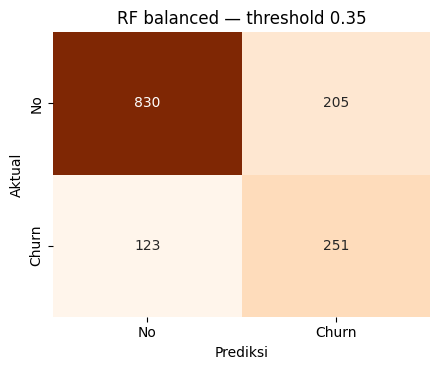

In [6]:
proba_bal = rf_bal.predict_proba(X_te)[:, 1]
rows = []
for t in [0.50, 0.40, 0.35, 0.30]:
    pred = (proba_bal >= t).astype(int)
    rows.append({
        'threshold': t,
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred, pos_label=1),
        'Recall': recall_score(y_te, pred, pos_label=1),
        'F1': f1_score(y_te, pred, pos_label=1),
    })
tbl = pd.DataFrame(rows).round(3)
print(tbl.to_string(index=False))

pred_035 = (proba_bal >= 0.35).astype(int)
cm_035 = confusion_matrix(y_te, pred_035, labels=[0, 1])
plt.figure(figsize=(4.5, 3.8))
sns.heatmap(
    cm_035, annot=True, fmt='d', cmap='Oranges', cbar=False,
    xticklabels=['No', 'Churn'], yticklabels=['No', 'Churn']
)
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.title('RF balanced — threshold 0.35')
plt.tight_layout()
plt.show()


### Interpretasi metrik (accuracy paradox)

- Dataset ~73.5% tidak churn. Model yang selalu prediksi No sudah dapat Accuracy ~0.73 tanpa menangkap satu pelanggan pun yang pergi.
- Di threshold 0.5, `class_weight="balanced"` **belum** menaikkan Recall (0.503 vs 0.524). Accuracy kedua model hampir sama (~0.79) — ini contoh accuracy paradox: angka akurasi tidak membedakan model yang berguna untuk retensi.
- Menurunkan threshold ke **0.35** pada model balanced menaikkan Recall churn secara material, dengan Precision yang turun. Itu trade-off yang masuk akal: lebih baik tim retensi menghubungi beberapa pelanggan yang ternyata bertahan, daripada melewatkan pelanggan yang benar-benar pergi.
- Metrik yang relevan: **Recall / F1 kelas churn** dan ROC-AUC, bukan Accuracy.


## Langkah 5: Probabilitas Churn dan Feature Importance

`predict_proba` dipakai untuk ranking pelanggan berisiko tinggi — lebih berguna untuk tim retensi daripada label 0/1 semata.


10 pelanggan test dengan probabilitas churn tertinggi:
 tenure  MonthlyCharges  churn_aktual  proba_churn
      1           69.60             1        1.000
      1           69.55             1        0.993
      1           76.45             1        0.990
      1           79.50             1        0.990
      1           69.90             1        0.987
      1           69.90             0        0.987
      1           85.05             1        0.977
      1           35.55             1        0.973
      2           84.05             0        0.970
      2           85.70             1        0.963

Rata-rata proba pelanggan yang benar-benar churn : 0.495
Rata-rata proba pelanggan yang tidak churn       : 0.186

Feature importance (top 8):
                         Fitur  Importance
                  TotalCharges    0.179577
                        tenure    0.163862
                MonthlyCharges    0.150221
             Contract_Two year    0.059397
   InternetService_Fiber 

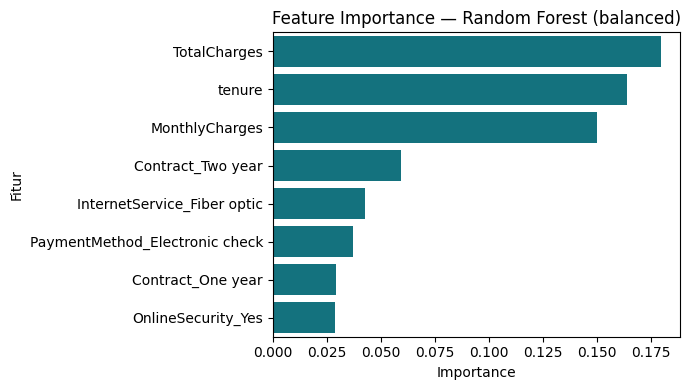

In [7]:
ranking = pd.DataFrame({
    'tenure': X_te['tenure'].values,
    'MonthlyCharges': X_te['MonthlyCharges'].values,
    'churn_aktual': y_te.values,
    'proba_churn': proba_bal.round(3)
}).sort_values('proba_churn', ascending=False)

print('10 pelanggan test dengan probabilitas churn tertinggi:')
print(ranking.head(10).to_string(index=False))
print()
print('Rata-rata proba pelanggan yang benar-benar churn :',
      proba_bal[y_te == 1].mean().round(3))
print('Rata-rata proba pelanggan yang tidak churn       :',
      proba_bal[y_te == 0].mean().round(3))

imp = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_bal.feature_importances_
}).sort_values('Importance', ascending=False)
print()
print('Feature importance (top 8):')
print(imp.head(8).to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=imp.head(8), x='Importance', y='Fitur', color='#028090')
plt.title('Feature Importance — Random Forest (balanced)')
plt.tight_layout()
plt.show()


## Kesimpulan

### Apa yang Dipelajari
- Ensemble bagging: Random Forest menggabungkan banyak Decision Tree agar prediksi lebih stabil
- Imbalanced dataset dan accuracy paradox: Accuracy tinggi tidak berarti model berguna
- `class_weight="balanced"` dan **threshold tuning** sebagai penanganan di level algoritma; test set tetap distribusi asli
- Evaluasi churn memakai Precision, Recall, F1, ROC-AUC, plus `predict_proba` untuk prioritas retensi

### Temuan Utama
- Telco Customer Churn: 7.043 pelanggan, 26.5% churn
- Tanpa penanganan (threshold 0.5): Accuracy 0.794, Recall churn 0.524, F1 0.575, ROC-AUC 0.827
- `class_weight="balanced"` (threshold 0.5): Accuracy 0.792, Recall 0.503 — hampir sama, Accuracy tidak membantu memilih model
- Threshold 0.35 pada model balanced: Recall churn naik ke **0.671** (dari 0.503), F1 0.605, Precision turun ke 0.550
- Fitur paling berpengaruh: `TotalCharges`, `tenure`, `MonthlyCharges`, lalu jenis kontrak

### Keterbatasan
- Belum memakai SMOTE (opsi level-data di modul); threshold tuning sudah cukup untuk menunjukkan trade-off Recall/Precision
- Encoding one-hot sederhana; interaksi fitur tidak direkayasa manual
- Dataset publik, bukan data operator lokal — generalisasi ke pasar Indonesia terbatas
